# **Lab 2: Digital Imaging Fundamentals with Python**
**Course:** AI342 Image Processing  
**University:** Taibah University  
**College:** Computer Science and Engineering  
**Department:** AI & DS

---
## **Learning Objectives**
* Relate human visual system properties to digital image perception.
* Demonstrate brightness adaptation and contrast effects.
* Simulate sampling and quantisation.
* Work with pixel neighbourhoods and distance measures.
* Apply basic geometric transformations.

In [1]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt

## **1. Human Visual Perception: Mach Bands**
**Exercise 1.1:** Simulating Mach bands to show how our eyes perceive transitions.

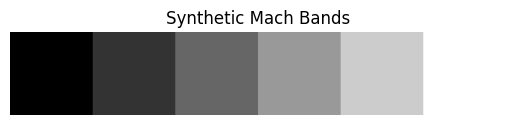

'\nThey are only present in human perception. In the data, \nthe box is as the same intensity level as the boundries. \n'

In [2]:
# Create Mach Bands
bands = np.zeros((100, 600))
for i in range(6):
    # rows, columns
    bands[:, i*100 : (i+1)*100] = i*40

plt.imshow(bands, cmap='gray')
plt.title("Synthetic Mach Bands")
plt.axis('off')
plt.show()

# Questions 
# 1. Do the boundaries between bands appear sharper than the interiors? 
'''
Yes, they appear sharper and darker than the box intensity level itself.
This is a subjective observation.
'''
# 2. Are these sharp transitions present in the data or only in perception?
'''
They are only present in human perception. In the data, 
the box is as the same intensity level as the boundries. 
'''

## **2. Simultaneous Contrast**
**Exercise 2.1:** Perceived brightness depends on the background.

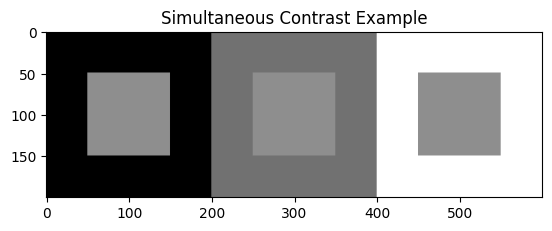

'The boxes in the middle all have the same intensity color. This is also a subjective notice to\nhuman eye that they kind of look different in each band. But in the data, they are all the same.'

In [3]:
img = np.ones((200, 600)) * 100
img[:, :200] = 20
img[:, 400:] = 200
img[50:150, 250:350] = 120
img[50:150, 50:150] = 120
img[50:150, 450:550] = 120

plt.imshow(img, cmap='gray')
plt.title("Simultaneous Contrast Example")
# plt.axis('off')
plt.show()

# Questions 
# 1. Does the central rectangle appear equally bright on both backgrounds? 
'''No, in human prespective, the gray box in the missle appears to have different intensity 
levels due to the color of the background.'''
# 2. What does this imply for interpreting pixel values visually? 
'''The boxes in the middle all have the same intensity color. This is also a subjective notice to
human eye that they kind of look different in each band. But in the data, they are all the same.'''

## **3. Image representation as a matrix**

Recall that an image consists of M rows and N columns, with pixel values typically in the 
range 0 to 255. 

**Exercise 3.1:** Inspecting image structure 

In [4]:
# Create a random image for testing

# start, end, size
image = np.random.randint(0, 256, (256, 256))

print(image.shape) 
print(image.min(), image.max())

# Task 
# Explain how this array corresponds to f(x, y) as defined in the lecture.
'''This numpy array creates a 256 by 256 matrix filled with random values
in the range between 0 and 255. each number inide this matrix will be presented 
as a pixel with the spatial coordinates f(x,y). For example, the first pixel is at the 
location f(0,0) and it has the value 238.'''

(256, 256)
0 255


'This numpy array creates a 256 by 256 matrix filled with random values\nin the range between 0 and 255. each number inide this matrix will be presented \nas a pixel with the spatial coordinates f(x,y). For example, the first pixel is at the \nlocation f(0,0) and it has the value 238.'

## **4. Sampling and spatial resolution**

Sampling determines the number of pixels used to represent a scene. 

**Exercise 4.1:** Down sampling an image 

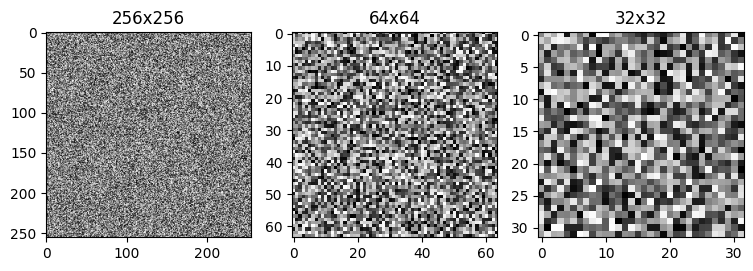

1 255


In [5]:
# Downsampling
down_64 = image[::4, ::4] # discard 4 steps
down_32 = image[::8, ::8] # discard 8 steps

plt.figure(figsize=(9,3))
plt.subplot(1,3,1); plt.imshow(image, cmap='gray'); plt.title("256x256")
plt.subplot(1,3,2); plt.imshow(down_64, cmap='gray'); plt.title("64x64")
plt.subplot(1,3,3); plt.imshow(down_32, cmap='gray'); plt.title("32x32")
plt.show()

# Questions 
# 1. Which image shows the greatest loss of detail?
'''The 32 by 32 image. It has the greates loss due to the huge amount of pixels 
eliminated from the original image.''' 
# 2. Has the number of grey levels changed? 
'''No, it remains the same.'''

print(down_32.min(), down_32.max())

## **5. Quantisation (Intensity Resolution)**

Quantisation determines how many intensity levels are available. 

**Exercise 5.1:** Reducing the number of grey levels.

[  0  16  32  48  64  80  96 112 128 144 160 176 192 208 224 240] [  0  64 128 192]


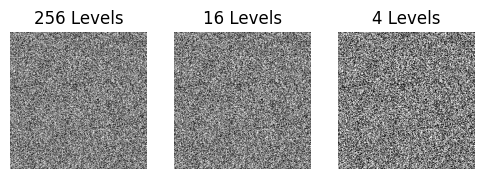

"\nEach level has a determined number of bits that hold the information of the \nintensity level. A 256 levels will be stored in 8 bits. A 16 levels image's pixels \nwill be stored in 4 bits. A 4 level image's pixels will be stored in 2 bits.\n"

In [6]:
def quantise(img, levels):
    step = 256 // levels
    return (img // step) * step

q256 = quantise(image, 256)
q16 = quantise(image, 16)
q4 = quantise(image, 4)


print(np.unique(q16), np.unique(q4))

plt.figure(figsize=(6,3))
plt.subplot(1,3,1); plt.imshow(q256, cmap='gray'); plt.title("256 Levels");plt.axis('off')
plt.subplot(1,3,2); plt.imshow(q16, cmap='gray'); plt.title("16 Levels");plt.axis('off')
plt.subplot(1,3,3); plt.imshow(q4, cmap='gray'); plt.title("4 Levels");plt.axis('off')
plt.show()

# Questions 
# 1. At which level does banding become noticeable? 
'''
At level 4. All the pixels will have only four intensity levels 
depending on their original level. This would impact the image's quality and 
objects' visibility
'''
# 2. How does this relate to bits per pixel? 
'''
Each level has a determined number of bits that hold the information of the 
intensity level. A 256 levels will be stored in 8 bits. A 16 levels image's pixels 
will be stored in 4 bits. A 4 level image's pixels will be stored in 2 bits.
'''

## **6. Sampling vs quantisation**

**Exercise 6.1:** Conceptual comparison 

Using your results from Exercises 4 and 5: 

- Identify which process affects spatial detail 
- Identify which process affects intensity smoothness 

In [7]:
# Write a short explanation. 
'''Sampling Affects the Spatial details. It works by cropping and joining
rows and columns of the image itself, without changing the values of the 
pixels themselves.

In the other hand, intensity smoothness is affected by quantisation. It is the 
process of changing the pixels values into a lower level. An image of 256 level
would look smoother. Each pixel will have a range of 0 to 255 to be assigned to.
These display pretty smooth images with appealing shapes. Lowering intensitiy 
levels means lowering the variaty of the level range an image would have.'''

'Sampling Affects the Spatial details. It works by cropping and joining\nrows and columns of the image itself, without changing the values of the \npixels themselves.\n\nIn the other hand, intensity smoothness is affected by quantisation. It is the \nprocess of changing the pixels values into a lower level. An image of 256 level\nwould look smoother. Each pixel will have a range of 0 to 255 to be assigned to.\nThese display pretty smooth images with appealing shapes. Lowering intensitiy \nlevels means lowering the variaty of the level range an image would have.'

## **7. Pixel neighbourhoods and adjacency** 

**Exercise 7.1:** N4 and N8 neighbourhoods 

In [8]:
x = 5
y = 5
p = (x, y)

# Student Task: Define the coordinates relative to p
def N4_neighbor(p):
    return [(p[0]+1,p[1]), (p[0]-1,p[1]), (p[0],p[1]+1), (p[0],p[1]-1)]

def N8_neighbor(p):
    return N4_neighbor(p) + [(p[0]+1,p[1]+1), (p[0]+1,p[1]-1), (p[0]-1,p[1]-1), (p[0]-1,p[1]+1)]

N4 = N4_neighbor(p) # Fill here
N8 = N8_neighbor(p) # Fill here

print("N4 Neighbourhood:", N4)
print("N8 Neighbourhood:", N8)

# Questions 
# 1. Why does 8 adjacency sometimes create ambiguity? 
'''
Beacuase it is a little wider in space and it can be tricky considering the 
spatial coordinates on an image has an inverse increasing direction in the y-axis.
'''
# 2. When is m adjacency preferred? 
'''
To define all paths of adjacent pixels. This pretty effecient in object segmentation
applications which the main task is to detect an object's edge pixels as accurate
as possible.
'''

N4 Neighbourhood: [(6, 5), (4, 5), (5, 6), (5, 4)]
N8 Neighbourhood: [(6, 5), (4, 5), (5, 6), (5, 4), (6, 6), (6, 4), (4, 4), (4, 6)]


"\nTo define all paths of adjacent pixels. This pretty effecient in object segmentation\napplications which the main task is to detect an object's edge pixels as accurate\nas possible.\n"

## **8. Distance Measures between pixels**

**Exercise 8.1:** Distance computation 

**Task:** Implement the formulas for Euclidean, City-block ($D_4$), and Chessboard ($D_8$) distances.

In [9]:
import math

p = (2, 3)
q = (7, 9)

# Student Task: Implement the formulas
D_euclid = math.sqrt(((p[0]-q[0])**2 + (p[1]-q[1])**2)) # Hint: use math.sqrt
D4 = abs(p[0]- q[0]) + abs(p[1]- q[1])      # Hint: use abs(x1-x2) + abs(y1-y2)
D8 = max(abs(p[0]- q[0]), abs(p[1]- q[1]))       # Hint: use max(abs(x1-x2), abs(y1-y2))

print(f"Euclidean: {D_euclid:.2f}")
print(f"City-block(D4): {D4:.2f}")
print(f"Chessboard (D8): {D8:.2f}")

# Questions 
# 1. Which distance corresponds to N4 adjacency? 
'''
City Block Distance
'''
# 2. Which corresponds to N8 adjacency? 
'''
Chessboard Distance
'''

Euclidean: 7.81
City-block(D4): 11.00
Chessboard (D8): 6.00


'\nChessboard Distance\n'

## **9. Geometric Transformations**
**Exercise 9.1 & 10.1:** Image Translation and Interpolation.

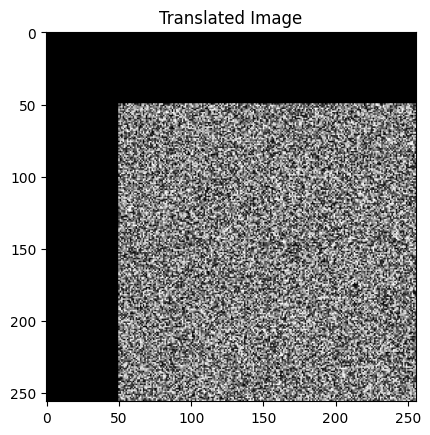

In [12]:
'''
Image Translation is shifting each pixel into a new position
without changing its intensity values. pixel in (x,y) will be shifted into (x`,y`).
Shifted image in space will have empty pixels in the old positions, zero padding 
was used here to fill empty pixels.
'''

# Write the code here
translated = np.zeros_like(image) 
translated[50:, 50:] = image[:-50, :-50] 
 
plt.imshow(translated, cmap='gray') 
plt.title("Translated Image") 
plt.show() 

## **10. Image scaling and interpolation** 

**Exercise 10.1:** Nearest neighbour zoom 

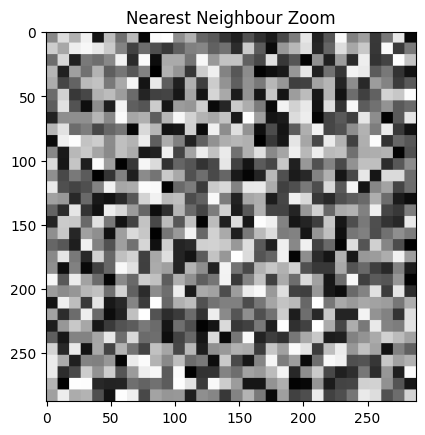

'\nBecause we zoomed in a 32x32 image which can show smaller details look pixely.\n'

In [18]:
'''
Image Interpolation is the filler of pixels with unknown intensities.
It can be used after any kind of transformation that cause the creation
of new pixels. 

This is nearest neighbor zoom that only duplicate pixels making them look blocky. 
'''

zoom = np.repeat(np.repeat(down_32, 9, axis=0), 9, axis=1) 
 
plt.imshow(zoom, cmap='gray') 
plt.title("Nearest Neighbour Zoom") 
plt.show() 

# Questions 
# 1. Why does the image appear blocky? 
'''
Because we zoomed in a 32x32 image which can show smaller details look pixely.
'''
# 2. Which interpolation method would improve smoothness? 

## **11. Reflection & Mini Project**
**Task:**

1.	Start with a grey scale image
2.	Create three versions with different spatial resolutions
3.	Create three versions with different intensity resolutions
4.	Comment on which degradation affects interpretability more and why

**Your explanation must reference:**


•	Sampling

•	Quantisation

•	Human visual perception
________________________________________

***Note:***

 Organize your project into logical steps using separate cells, include a Text Cell before each stage to explain your approach, and ensure all results are clearly visualized using titles and subplots

**Reflection questions**

1.	Why is a digital image always an approximation of reality?

2.	How does human perception complicate objective image analysis?

3.	Why is interpolation unavoidable in geometric transformations?